This notebook explores [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and [Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) classifiers using [sklearn](https://scikit-learn.org/stable/index.html). It describes how these algorithms work so one can better tune data and parameters for working with them and exploiting their features. It also introduces a model interpretability technique using [Shapley values](https://christophm.github.io/interpretable-ml-book/shapley.html).

**Author:** Tom McTavish

# What's covered

We cover the following:

  * How Decision Trees work.
    * Splitting criterion
  * How Random Forests work.
    * Bootstrap sampling
  * How Isolation Forests relate to Random Forests and why they are a tool for anomaly detection.
  * Data optimization for these algorithms.
  * Dealing with unbalanced data (sorta).
  * How to deal with NULLs.
  * Parameter tuning.
  * Capturing feature importances.
  
> **NOTE:** This notebook assumes all required Python packages are installed. If you get an import error, from the command line, try to install with `pip install the-missing-package` or `conda install the-missing-package` if you use conda and then see if the notebook works.
  

# Introduction

## Quick note on randomness

In this presentation, we will see randomness applied throughout, which gives rise to the "random" in Random Forests. Through ways of being random, but then making simple, educated decisions given some local measure, the algorithm toggles between biased and unbiased states. Please appreciate how effective it is!

## Ensemble methods

A Random Forest (RF) is a collection of [Decision Trees](https://scikit-learn.org/stable/modules/tree.html), which is a type of classification algorithm. As a collection of trees, the Random Forest is a type of *ensemble method* that aggregates the classification of typically weak and poor classifiers into a final, weighted classification vote. As such, not only do we get the majority vote, but we can also obtain the relative strength or probability the model ascribes to various classes when it makes a prediction. To understand RFs, we have to understand Decision Trees that make up the forest.


# [Decision Tree](https://scikit-learn.org/stable/modules/tree.html)

## Overview

A Decision Tree (for our purposes, using the Sklearn approach) is a binary decision graph where each node progressively segments its input data into two subsets along a feature value. Typically, optimal decisions are those that promote the best separation of the data. In the case of two classes, an optimal split is a split that has maximal separation of one class on one side of the decision boundary and the other class on the other side of the boundary.

### Example

We will use the [Iris Flower Dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) as an example.

#### The Iris Flower Dataset

The classification goal of the Iris Flower Dataset is to place irises into one of 3 classes, shown below in 3 colors, using measurements along 4 dimensions.

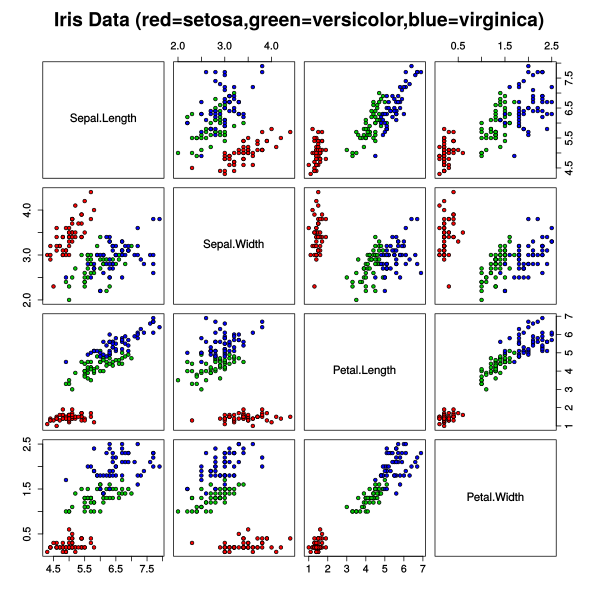

In [1]:
from IPython.display import SVG, display
import requests

def show_svg():
    url = 'https://upload.wikimedia.org/wikipedia/commons/5/56/Iris_dataset_scatterplot.svg'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    response = requests.get(url, headers=headers)
    return SVG(data=response.content)

display(show_svg())

#### Classifying with a decision tree

We will pilfer from [sklearn's example](https://scikit-learn.org/stable/auto_examples/tree/plot_iris_dtc.html#sphx-glr-auto-examples-tree-plot-iris-dtc-py) to show how a single decision tree can be trained on this dataset.

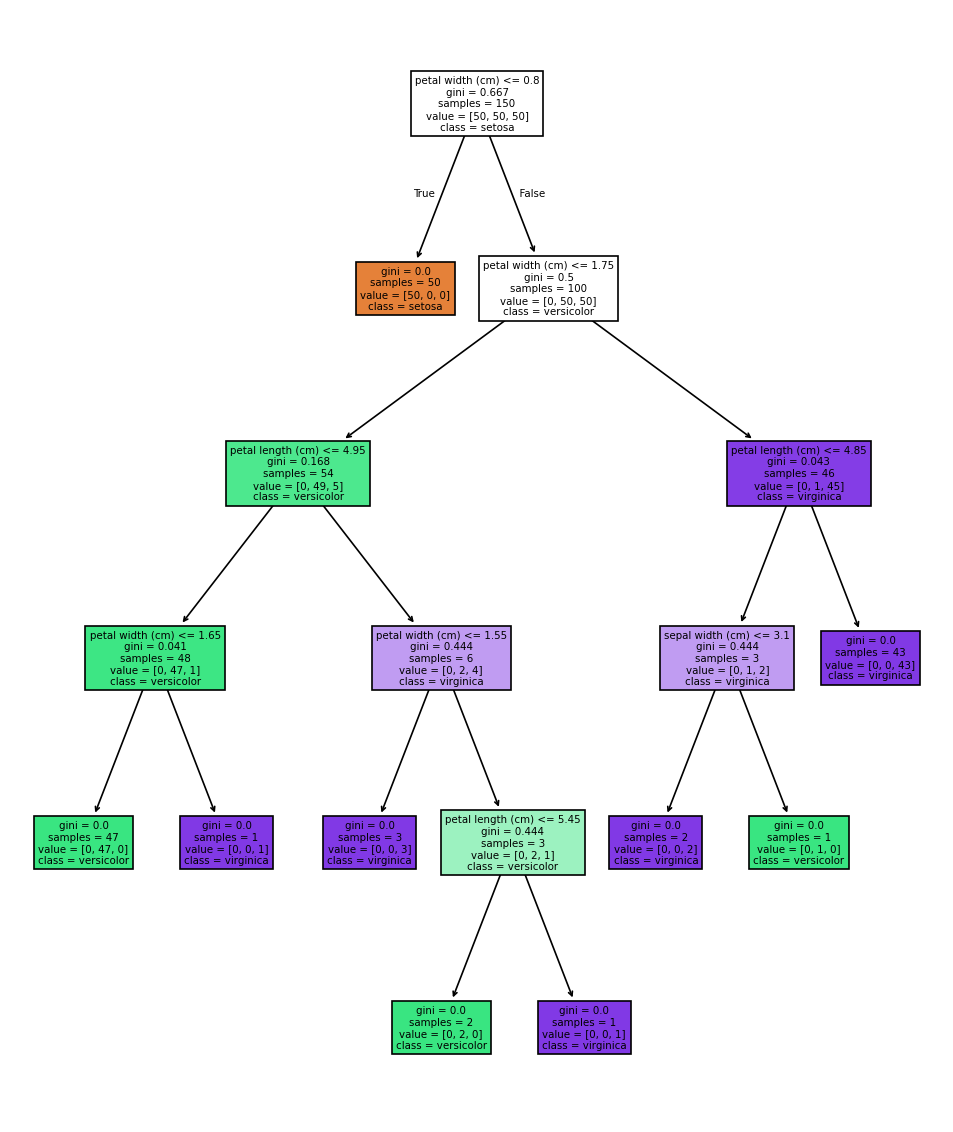

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pal = sns.color_palette('colorblind')
sns.set_palette(pal)

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load data
iris = load_iris()
n_classes = len(iris.target_names)

plt.figure(figsize=(10, 12), dpi=120)
clf = DecisionTreeClassifier(random_state=0).fit(iris.data, iris.target)
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True);

The figure above shows a decision tree trained on this dataset. Right off the bat, we can see that all it did to separate *setosa* from the other two classes is split the data where *petal width* is <= 0.8. That leaves 100 samples from the other two classes to work with. By splitting *petal width* again at 1.75, the left node contains 54 samples, 49 that are *versicolor* and 5 that are *virginica*. Similarly, the right node has a strong distribution of *virginica* and only 1 *versicolor*. You can see how the data keeps segmenting.

## The Decision Tree Algorithm: Randomness and Gini magic

The decision tree is built by:

  1. Arbitrarily choosing $n$ features. For models with few features, or if computation is not a problem, all features can be used. (The selection of feature subsets becomes more important with random forests.)
  2. With each randomly chosen feature, for $m$ times, we split of the data along some random value of that feature. Since the distribution of the data along a given dimension/feature is rarely known, this is usually a uniformly random split from the training data's min and max values along that dimension.
  3. With each split, we ask how good it is. "Good" is often measured with the *Gini Impurity index*, described below or as *entropy* from an information theoretic point of view. Regardless, these values seek a decision boundary that optimally splits the data such that the bulk of samples on one side belong to one subset of classes and the bulk of the other samples belong to a different subset.
  4. After $n$ features have each been split $m$ times, we take the feature-split that best splits the data.
  5. Keep recursing this process with the resulting two children nodes until no more samples are found or other stopping criteria is reached.
  
### Gini Impurity Index

As summarized in [this excellent post](https://victorzhou.com/blog/gini-impurity/): "Gini Impurity is the probability of incorrectly classifying a randomly chosen element in the dataset if it were randomly labeled according to the class distribution in the dataset." It is defined as:

$G = \Sigma_{i=1}^{C}p(i)*(1-p(i))$

where $C$ is the number of classes and $p(i)$ is the probability of class $i$ in the sample. For two classes, this is has a maximum possible value at 0.5. If it is near zero, then this means it is a poor decision boundary because we can largely expect one class over others.

The figure below plots *entropy*, *Gini impurity*, and misclassification errors when seeking an optimal split for a given subset of data. 

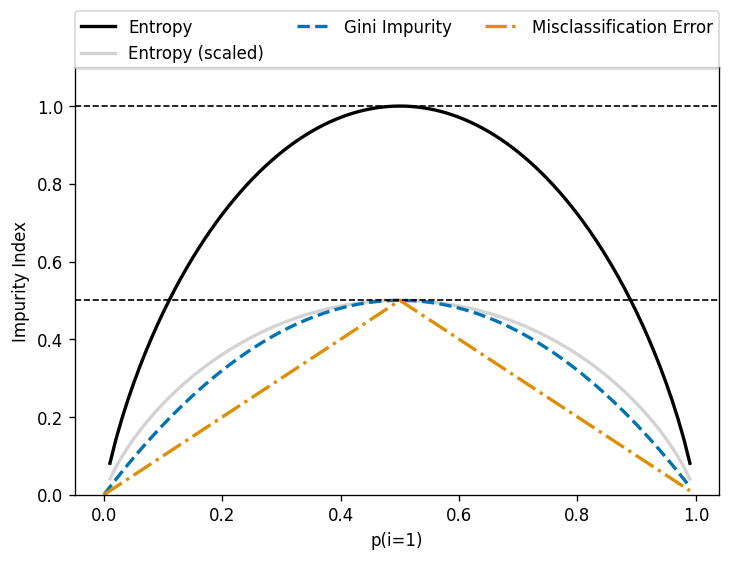

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def gini(p):
    return (p)*(1 - (p)) + (1-p)*(1 - (1-p))

def entropy(p):
    return - p*np.log2(p) - (1 - p)*np.log2((1 - p))

def error(p):
    return 1 - np.max([p, 1 - p])

x = np.arange(0.0, 1.0, 0.01)

ent = [entropy(p) if p != 0 else None for p in x]
sc_ent = [e*0.5 if e else None for e in ent]
err = [error(i) for i in x]

fig = plt.figure(dpi=120)
ax = plt.subplot(111)
for i, lab, ls, c, in zip([ent, sc_ent, gini(x), err], 
                  ['Entropy', 'Entropy (scaled)', 
                   'Gini Impurity', 'Misclassification Error'],
                  ['-', '-', '--', '-.'],
                  ['black', 'lightgray', pal.as_hex()[0], pal.as_hex()[1], pal.as_hex()[2]]):#'red', 'green', 'cyan']):
    line = ax.plot(x, i, label=lab, linestyle=ls, lw=2, color=c)



ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          ncol=3, fancybox=True, shadow=False)

ax.axhline(y=0.5, linewidth=1, color='k', linestyle='--')
ax.axhline(y=1.0, linewidth=1, color='k', linestyle='--')
plt.ylim([0, 1.1])
plt.xlabel('p(i=1)')
plt.ylabel('Impurity Index')
plt.tight_layout()


### The importance of uniform distributions.

Let us consider what the Decision Tree is doing: It takes the minimum and maximum range of a given feature, then samples uniformly $n$ cuts in that range. If the distribution of the feature is NOT uniform, then the algorithm will make suboptimal cuts. This may not be important if distributions are somewhat near a uniform distribution, but it will become important if the distributions are not.

#### Example

Consider the following toy example that has two classes along some feature dimension and 5 random cuts uniformly distributed. 

**Left Panel)** For one of the classes, the distribution is largely exponential. For the other class, the feature is distributed more Gamma-like. Regardless, most of the values are on the lower end. If we randomly split uniformly between the raw minimum and maximum values of the feature, we will be calculating decisions in the tail, which will be rejected and we lose the resolution of a refined decision boundary.

**Middle Panel)** The distributions of the two classes are now displayed by their quantile values with the same cuts from the left panel projected into this space.

**Right Panel)** The distributions of the two classes are now displayed by their quantile values with the uniform cuts now in the uniformly distributed feature.

In [4]:
from sklearn.preprocessing import QuantileTransformer

In [5]:
np.random.seed(42)
size = 20_000
rng = np.random.default_rng()
rand_sigmoid = rng.logistic(scale=.1, size=size)
orig = rng.exponential(size=size)
q_tx = QuantileTransformer()
qtiles = q_tx.fit_transform(orig.reshape(-1, 1)).flatten()
cls = np.array((qtiles + rand_sigmoid) > .5, dtype=int)

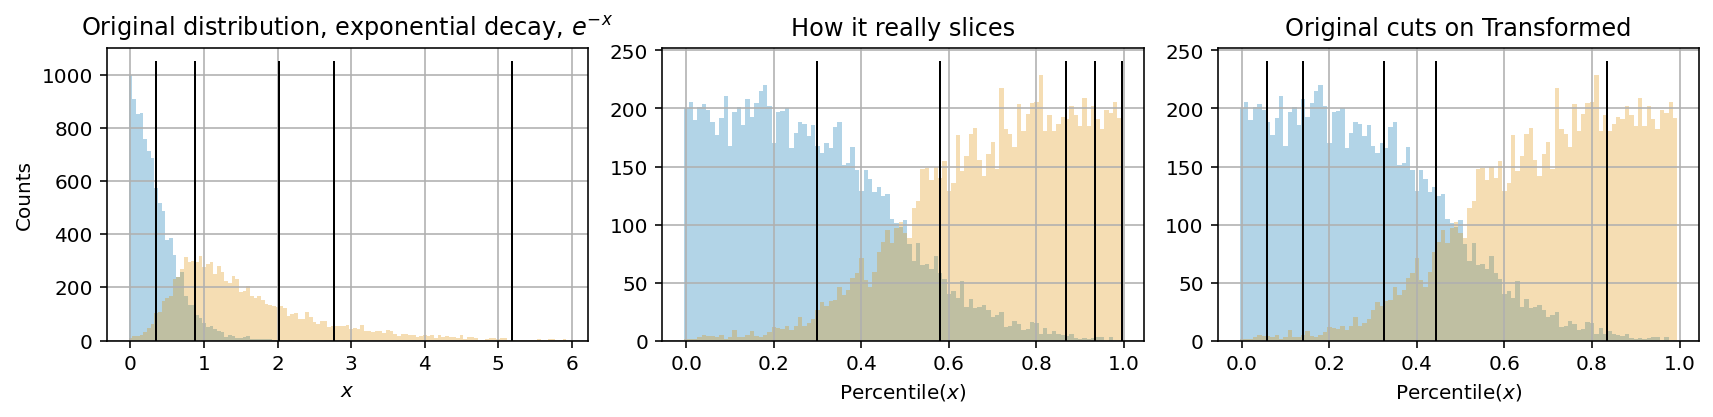

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,3), dpi=144, tight_layout=True)
alpha = .3
lc = 'black'  # color_cycle[1]  # Second color in our palette
h0, bins = np.histogram(orig[cls==0], bins=np.arange(0,6,.05))
width = bins[1]-bins[0]
axes[0].bar(x=bins[:-1], height=h0, width=width, alpha=alpha)

h1, bins = np.histogram(orig[cls==1], bins=bins)
axes[0].bar(x=bins[:-1], height=h1, width=width, alpha=alpha)
axes[0].set_title('Original distribution, exponential decay, $e^{-x}$');
axes[0].set_ylabel('Counts')
axes[0].set_xlabel('$x$')
axes[0].grid();

cuts = np.random.uniform(size=5)
xlim_max = axes[0].get_xlim()[-1]
cuts *= xlim_max
ylim_max = axes[0].get_ylim()[-1]
for c in cuts:
    axes[0].plot([c, c], [0, ylim_max], color=lc, lw=1)

qtiles0 = q_tx.transform(orig[cls==0].reshape(-1, 1))
hq0, bins = np.histogram(qtiles0, bins=np.linspace(0, 1, 101))
width = bins[1]-bins[0]
axes[1].bar(x=bins[:-1], height=hq0, width=width, alpha=alpha)
qtiles1 = q_tx.transform(orig[cls==1].reshape(-1, 1))
hq1, bins = np.histogram(qtiles1, bins=bins)
axes[1].bar(x=bins[:-1], height=hq1, width=width, alpha=alpha)

axes[1].set_title('How it really slices');
# axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Percentile$(x)$')
axes[1].grid();
ylim_max = axes[1].get_ylim()[-1]
for c in cuts:
    cq = q_tx.transform(c.reshape(1, -1))[0][0]
    axes[1].plot([cq, cq], [0, ylim_max], color=lc, lw=1)

axes[2].bar(x=bins[:-1], height=hq0, width=width, alpha=alpha)
axes[2].bar(x=bins[:-1], height=hq1, width=width, alpha=alpha)
axes[2].set_title('Original cuts on Transformed');
axes[2].set_xlabel('Percentile$(x)$')
axes[2].grid();

cuts /= xlim_max
for c in cuts:
    axes[2].plot([c, c], [0, ylim_max], color=lc, lw=1)
# fig.savefig('dist.png')

The lesson from the above is that transforming features into a uniform distribution is a way to optimize the Decision Tree results. Otherwise, the number of splits may need to be increased substantially in attempts to deal with non-uniform distributions, which only increases computation.

## Parameters

Sklearn's Decision Tree Classifier takes the following parameters:

  * `max_depth`: The deeper the tree, the more overfitted the tree may become.
  * `min_samples_split`: Values greater than this value will continue to segment the data.
  * `min_samples_leaf`: Minimum number of samples in the leaf nodes. Small values probably mean overfitting.
  * `max_features`: Maximum number of randomly selected features to work with.
  * `max_leaf_nodes`: Some trees can become rather sparse. Setting this to a constrained value achieves an optimal segmentation of the leaf nodes.
  * `min_impurity_decrease`: If the impurity does not change much, then there is little information gained by a proposed split. Setting this to a non-zero value means that it won't keep splitting and splitting for little gain. 
  * `class_weight`: For unbalanced classes, this can incorporate weights into the impurity calculations to rectify.
  
> Note: Smaller trees (and forests) often help models to generalize, are much faster during training and at inference time, and are much smaller in memory. Because these models train comparatively quickly, it's worth exploring parameter space. 

## Notes on data

Data is best if it is continuous and uniformly distributed. This means using something like [sklearn's StandardScalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) or [QuantileTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html). Otherwise, splits will not be optimal. For example, if data is really clustered and has sparse tails, since splits are sampled uniformly, then those splits will rarely concentrate in the clustered area where more resolution is needed.

Also, categorical variables aren't so great -- they have to map to a continuous number. Let's say we have 5 categorical variables that map to numbers 1, 2, 3, 4, and 5. Because splits are binary and not compound, the algorithm may struggle to segment "2" from the others. To do so would require splitting around 1.5 and again at 2.5. This implicitly associates classes 3, 4, and 5, which may be arbitrary and difficult for the algorithm.

# Random Forests

Random forests are collections of Decision Trees with a few tricks:

  * Each tree is typically constructed from a random subset of features.
  * Each tree is typically trained on a bootstrap sample of the training data.
  * The final prediction and class probabilities are averages of the trees.
  
## Making opinionated trees: Biodiversity via random feature subsets and bootstrap sampling

Let's consider the impact of the first two bullets above. 

#### Random feature subsets

By constraining the tree to only work with a subset of features, we are giving it a handicap, asking it to make the best decisions it can without its full arsenal of information-capturing capabilities. And some combinations of features that we constrain a tree to use are likely to be awful. What the hell!

By constraining each tree to certain features, we help give every feature a turn. Additionally, if the full feature set were available to each tree, very similar trees would likely be built because the decision points would be roughly the same. This would lead to high variance in the final model's output. Together, by enforcing different combinations of subsets, we get more diversity of feature space. And because the forest's classification is the average of the trees' outputs, weak trees of poor feature combinations will contribute less than stronger trees.

#### [Bootstrap sampling](https://en.wikipedia.org/wiki/Bootstrapping_(statistics))

A bootstrap sample is a sample of the training data, with replacement, the same size as the training data. By sampling with replacement, there is probability that some training examples are duplicated, triplicated, or more (the probability of replication falls exponentially) and some training examples are never used -- for that tree. This induces a biased tree, biased to accommodate those repeated examples more than others. Again, like the random feature subset selection described above, in aggregate, this counterintuitively creates a more diverse forest. Each tree is induced to be fairly opinionated by the subset of data and subset of features that it sees, but with a larger sampling -- the number of trees in the forest -- we capture the range of features and data and avoid local minima.

## Parameter Playground

The following code is modified from [here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html) and [here](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_anomaly_comparison.html) with some ipywidgets for parameter control.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification, make_blobs
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from ipywidgets import IntSlider, Checkbox, FloatSlider, interact_manual

h = .02  # step size in the mesh

# Example settings
n_samples = 300
outliers_fraction = 0.15

n_outliers = int(outliers_fraction * n_samples)
n_inliers = n_samples - n_outliers
n_estimators = 10

rf_model = RandomForestClassifier(n_estimators=n_estimators)
iso_model = IsolationForest(n_estimators=n_estimators, contamination=outliers_fraction, random_state=42)

X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           random_state=1, n_clusters_per_class=1)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

blobs_params = dict(random_state=0, n_samples=n_inliers, n_features=2)

datasets = [
            make_blobs(centers=[[-.5, -.5], [.5, .5]], cluster_std=0.5, **blobs_params),
            make_blobs(centers=[[-1, -1], [1, 1]], cluster_std=[0.5, 2], **blobs_params),
            make_moons(noise=0.05, random_state=0),
            make_moons(noise=0.3, random_state=0),
            make_circles(noise=0.2, factor=0.5, random_state=1),
            make_circles(noise=0.05, factor=0.5, random_state=1),
            linearly_separable
            ]

def plot_experiments(datasets, rf_model=None, iso_model=None, null_rate=0., lw=.5):
    n_cols = 1
    if rf_model is not None:
        n_cols += 1
    if iso_model is not None:
        n_cols += 1
        
    fig = plt.figure(figsize=(3.5*(n_cols), 3.5*len(datasets)))
    
    i = 1
    # iterate over datasets
    for ds_cnt, ds in enumerate(datasets):
        # preprocess dataset, split into training and test part
        X, y = ds
        X = StandardScaler().fit_transform(X)

        if null_rate > 0:
            for c in [0, 1]:
                min_x = X[:, c].min()
                r = X[:, c].max() - min_x
                r_max = min_x + r * 1.1

                indices = np.random.choice(np.arange(X[:, c].size), replace=False,
                                           size=int(X[:, c].size * null_rate))
                X[indices, c] = r_max

        X_train, X_test, y_train, y_test = \
            train_test_split(X, y, test_size=.3, random_state=42)

        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))

        # just plot the dataset first
        cm = plt.cm.RdBu
        cm_bright = ListedColormap(['#FF0000', '#0000FF'])
        ax = plt.subplot(len(datasets), n_cols, i)
        if ds_cnt == 0:
            ax.set_title("Input data")
        # Plot the training points
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
                   edgecolors='k', linewidth=lw)
        # Plot the testing points
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,
                   edgecolors='k', linewidth=lw, alpha=0.3)
        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_xticks(())
        ax.set_yticks(())
        i += 1

        if rf_model is not None:
            # iterate over classifiers
            ax = plt.subplot(len(datasets), n_cols, i)
            rf_model.fit(X_train, y_train)
            score = rf_model.score(X_test, y_test)

            Z = rf_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

            # Put the result into a color plot
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, cmap=cm, alpha=.8)

            # Plot the training points
#             ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright,
#                        edgecolors='k', lw=lw)
            # Plot the testing points
            ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright,
                       edgecolors='k', lw=lw)

            ax.set_xlim(xx.min(), xx.max())
            ax.set_ylim(yy.min(), yy.max())
            ax.set_xticks(())
            ax.set_yticks(())
            if ds_cnt == 0:
                ax.set_title('Random Forest')
            ax.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'),
                    size=15, horizontalalignment='right')
            i += 1

        if iso_model is not None:
            ax = plt.subplot(len(datasets), n_cols, i)
            if ds_cnt == 0:
                ax.set_title('Isolation Forest')

            y_pred = iso_model.fit(X).predict(X)

            # plot the levels lines and the points
            Z = iso_model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            plt.contour(xx, yy, Z, levels=[0], linewidths=1., colors='black')

            colors = np.array(['#377eb8', '#ff7f00'])
            ax.scatter(X[:, 0], X[:, 1], s=10, color=colors[(y_pred + 1) // 2])

            i += 1

    plt.tight_layout()
    plt.show()
    
n_estimators = IntSlider(min=1, max=100, step=1, value=10)
with_random_forest = Checkbox(value=True, description='With Random Forest')
with_isolation_forest = Checkbox(value=True, description='With Isolation Forest')
null_rate = FloatSlider(min=0, max=.5, step=.01, value=.1)

max_depth = IntSlider(min=1, max=100, step=1, value=10)
min_samples_split = IntSlider(min=2, max=100, step=1, value=2)
min_samples_leaf = IntSlider(min=1, max=100, step=1, value=1)
max_features = IntSlider(min=1, max=2, step=1, value=2)
max_leaf_nodes = IntSlider(min=1, max=100, step=1, value=100)
min_impurity_decrease = FloatSlider(min=0, max=.5, step=.001, value=0)
contamination = FloatSlider(min=0, max=.5, step=.01, value=.1)
max_samples = IntSlider(min=10, max=100, step=5, value=50)

random_state = IntSlider(min=1, max=100, step=1, value=42)

def run_experiment_interactive(**kwargs):
    return run_experiment(**kwargs)

def run_experiment(with_random_forest=False,
                   n_estimators=10,
                   with_isolation_forest=False,
                   null_rate=0.,
                   max_depth=10,
                   min_samples_split=2,
                   min_samples_leaf=1,
                   max_features=2,
                   max_leaf_nodes=100,
                   min_impurity_decrease=0.,
                   contamination=.1,
                   max_samples=100,
                   random_state=42,
                   ):
    global datasets
    
    rf_model = None
    iso_model = None
    if with_random_forest:
        rf_model = RandomForestClassifier(n_estimators=n_estimators, 
                                          max_depth=max_depth,
                                          min_samples_split=min_samples_split,
                                          min_samples_leaf=min_samples_leaf,
                                          max_features=max_features,
                                          max_leaf_nodes=max_leaf_nodes,
                                          min_impurity_decrease=min_impurity_decrease,
                                          random_state=random_state)   
    if with_isolation_forest:
        iso_model = IsolationForest(n_estimators=n_estimators,
                                    max_samples=max_samples,
                                    contamination=contamination,
                                    random_state=random_state)
    plot_experiments(datasets, rf_model, iso_model, null_rate=null_rate)

## Random Forest Parameterization

Adjust the parameters of the model to see the impact. In particular, `n_estimators=1` will make it so that the output is really a single decision tree. The colored background indicates the model's confidence for a particular class at for those feature values -- darker is more confident, lighter less confident.

In [8]:
_ = interact_manual(run_experiment_interactive, 
                    with_random_forest=with_random_forest,
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    max_leaf_nodes=max_leaf_nodes,
                    min_impurity_decrease=min_impurity_decrease,
                    random_state=random_state  
                   )

interactive(children=(Checkbox(value=True, description='With Random Forest'), IntSlider(value=10, description=…

## Dealing with NULLs

Many machine learning algorithms do not accommodate NaNs or NULL values. Therefore, one may need to impute a value. The imputation scheme is dependent on *why* the value is missing. If it simply wasn't captured, then assuming the median may be a valid imputation scheme. However, if its missing is meaningful, like you want to process the subset where a feature is NULL differently from where the feature is valid, then we have to ascribe it a value outside the normal range. Given that RFs split uniformly within the min-max range of a feature, if the imputed value was just outside this range by 10%, say, then we still keep most of our splitting resolution while give the opportunity for the RF to split NULLs from the others.

The following experiment adds a `null_rate` parameter, which sets that fraction of samples along either feature to NULL. In this case, we set those NULL values to 10% outside.

In [9]:
_ = interact_manual(run_experiment_interactive, 
                    with_random_forest=with_random_forest,
                    null_rate=null_rate,
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    max_leaf_nodes=max_leaf_nodes,
                    min_impurity_decrease=min_impurity_decrease,
                    random_state=random_state  
                   )

interactive(children=(Checkbox(value=True, description='With Random Forest'), FloatSlider(value=0.1, descripti…

## Feature importances

Given the impurity values of nodes in each tree of the forest, we can infer the relative importance of a feature. Sklearn offers two heuristics at feature importance. `model.feature_importances_`, which uses the impurity index and another tool, [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html), that permutes the values of a feature to determine how off it is from the trained model. These are shown below using the Iris dataset.

Feature ranking:
1. petal length (cm), (0.46044473961715215)
2. petal width (cm), (0.42411626512710127)
3. sepal length (cm), (0.09090795402103087)
4. sepal width (cm), (0.024531041234715754)


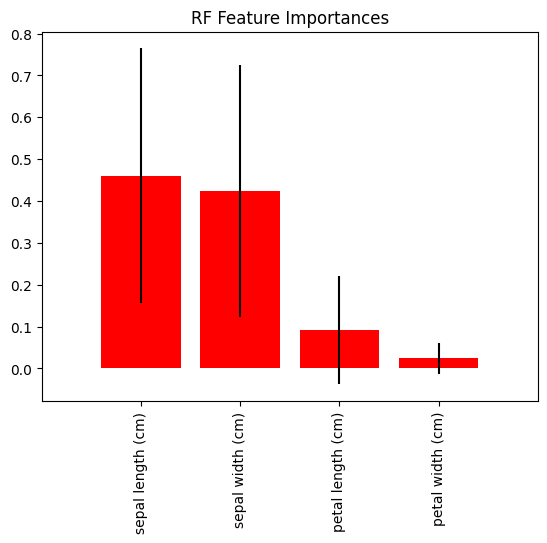

Feature ranking:
1. petal length (cm), (0.28933333333333333)
2. petal width (cm), (0.18066666666666667)
3. sepal length (cm), (0.015999999999999993)
4. sepal width (cm), (0.01133333333333334)


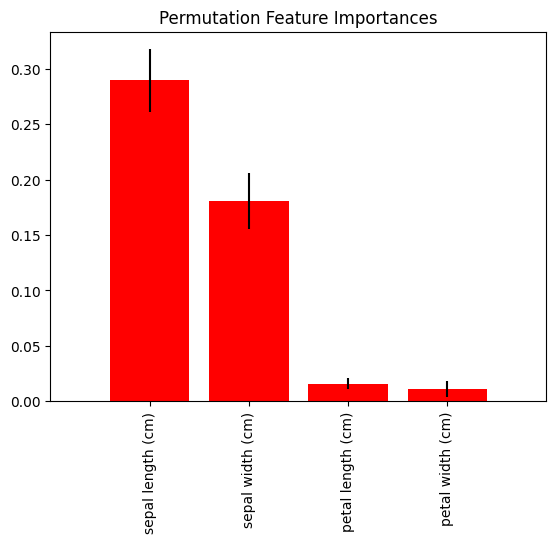

In [10]:
from sklearn.inspection import permutation_importance

def plot_feature_importances(importances, std, title='Feature importances'):
    indices = np.argsort(importances)[::-1]
    # Print the feature ranking
    print("Feature ranking:")

    for f in range(iris.data.shape[1]):
        print(f'{f+1}. {iris.feature_names[indices[f]]}, ({importances[indices[f]]})')

    # Plot the impurity-based feature importances of the forest
    plt.figure()
    plt.title(title)
    plt.bar(range(iris.data.shape[1]), importances[indices],
            color="r", yerr=std[indices], align="center")
    # plt.xticks(range(iris.data.shape[1]), indices)
    plt.xticks(range(iris.data.shape[1]), 
               iris.feature_names, rotation=90)

    plt.xlim([-1, iris.data.shape[1]])
    plt.show()
    
clf = RandomForestClassifier(random_state=0).fit(iris.data, iris.target)
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

plot_feature_importances(importances, std, title='RF Feature Importances')

result = permutation_importance(clf, iris.data, iris.target, n_repeats=10,
                                random_state=0)

importances = result.importances_mean

std = result.importances_std

plot_feature_importances(importances, std, title='Permutation Feature Importances')

Of the two options presented above, `permutation_importance` is generally the best. And it is applicable outside of Random Forests.

## Visualize feature importances with [SHAP](https://proceedings.neurips.cc/paper_files/paper/2017/file/8a20a8621978632d76c43dfd28b67767-Paper.pdf) values

Below are some examples exploring SHAP and model explainability.

In [11]:
# !pip install shap

In [12]:
import shap

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    *shap.datasets.iris(), test_size=0.2, random_state=0
)

shap.initjs()  # We need to init JavaScript in the notebook

explainer = shap.KernelExplainer(clf.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], X_test)

Using 120 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/30 [00:00<?, ?it/s]

### SHAP Feature importances

/var/folders/v3/19mnppn14813zq9cn89w0ty80000gp/T/ipykernel_12772/2519557014.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=iris.target_names, feature_names = X_test.columns)


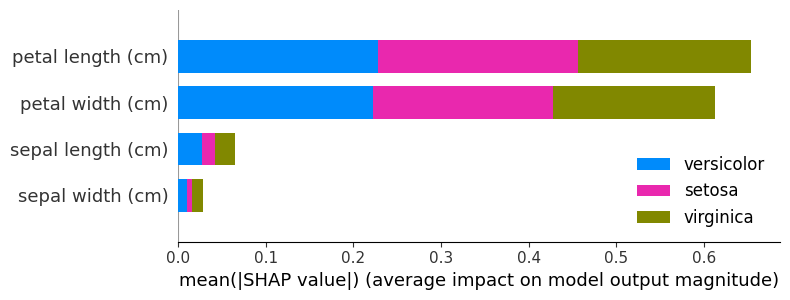

In [14]:
# Not sure what happened, but this should show feature importances.
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=iris.target_names, feature_names = X_test.columns)

/var/folders/v3/19mnppn14813zq9cn89w0ty80000gp/T/ipykernel_12772/763569737.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test.values, feature_names = X_test.columns)
/Users/tmctavish/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/Users/tmctavish/.venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence t

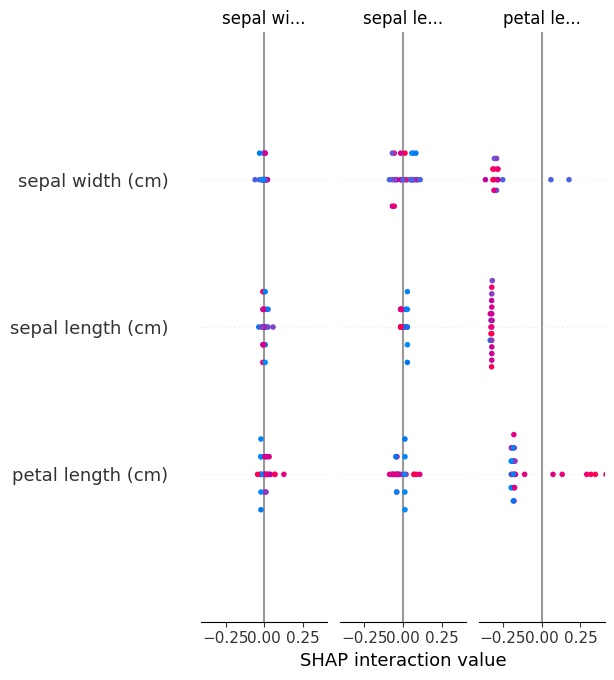

In [15]:
shap.summary_plot(shap_values, X_test.values, feature_names = X_test.columns)

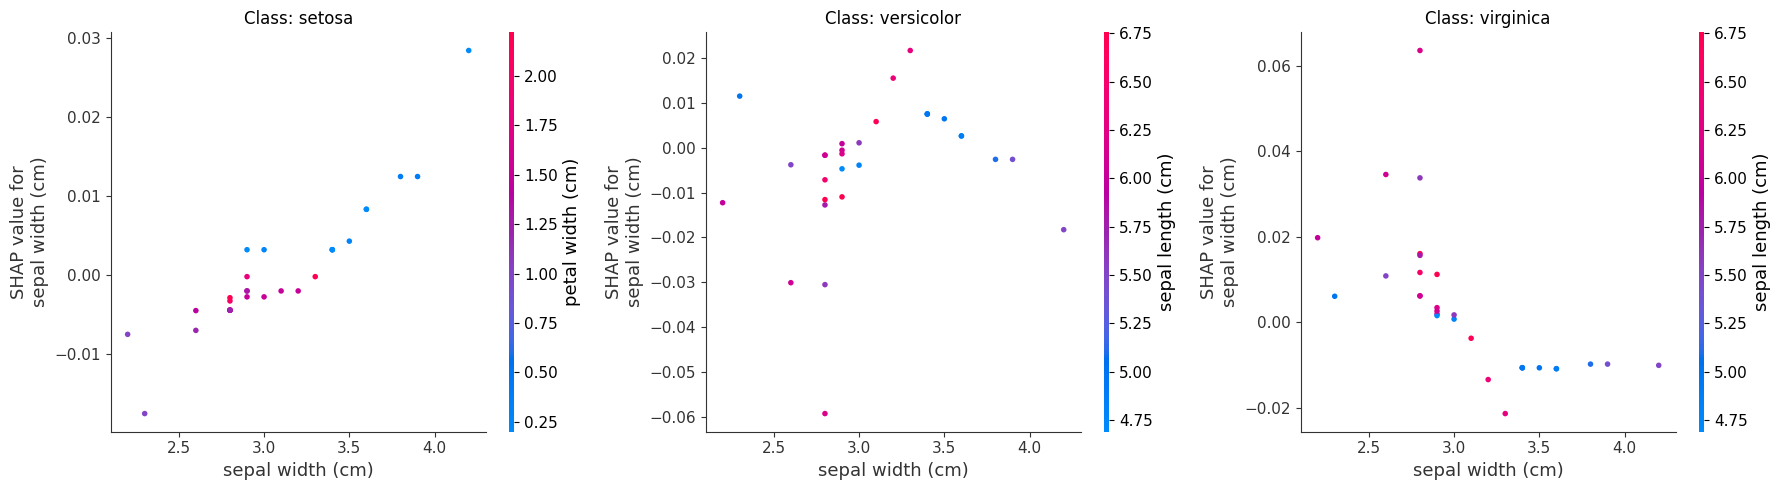

In [19]:
i = 1  # Feature index
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for class_idx, class_name in enumerate(iris.target_names):
    shap.dependence_plot(
        i,
        shap_values[..., class_idx],
        X_test.values,
        feature_names=X_test.columns.tolist(),
        ax=axes[class_idx],
        show=False
    )
    axes[class_idx].set_title(f"Class: {class_name}")

plt.tight_layout()
plt.show()

### Let's look at specific examples.

The following shows the first two samples of the test set. Notice that the class is not explicitly stated. There are 3 classes. The RED vs BLUE really highlights the relative scaling of being in-class (RED) or out-of-class (BLUE).

In [20]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test)
exp = shap.Explanation(shap_values.values[:,:,1], 
                  shap_values.base_values[:,1], 
                  data=X_test.values, 
                  feature_names=X_test.columns)

Change the `idx` value to select different samples in the test set to evaluate feature contributions.

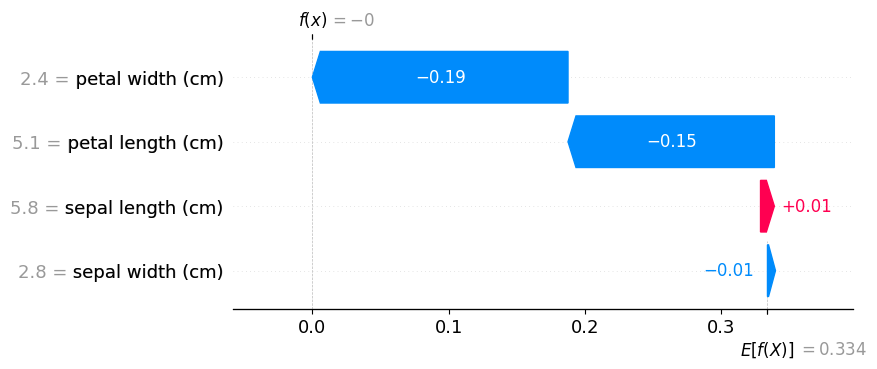

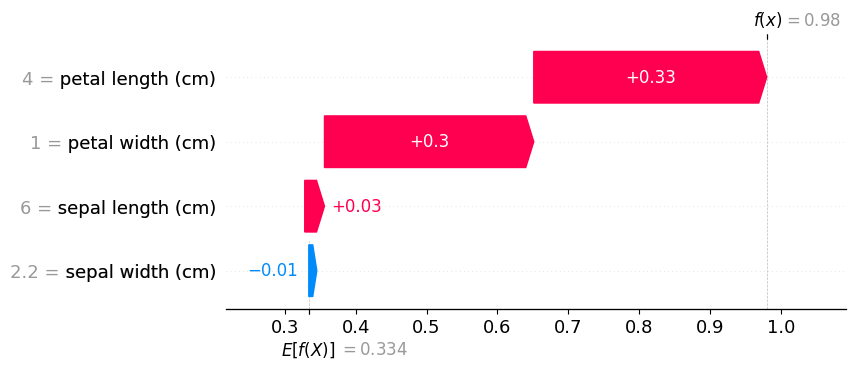

In [21]:
for idx in range(2):
    shap.plots.waterfall(exp[idx])

## [ExtraTrees](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html): Extremely randomized trees.

These are really the same as a Random Forest, but instead of each tree being constrained to some subset of features, a new random subset of features is selected for each node. These often perform a bit better than random forests, but depending on deployment availability, should maybe be avoided. For example, [PySpark](https://spark.apache.org/docs/latest/ml-classification-regression.html) supports Random Forests, but not Extremely Randomized Trees. If the model is deployed in PySpark, then sklearn prototyping should use the RandomForestClassifier.

# [Isolation Forests](https://en.wikipedia.org/wiki/Isolation_forest)

An Isolation Forest is unsupervised and is helpful for finding anomalies. Anomalies are "few and different" and therefore easier to isolate compared to normal examples [1](https://cs.nju.edu.cn/zhouzh/zhouzh.files/publication/tkdd11.pdf). The approach is rather simple:

```
  1. For $n$ number of desired trees:
  2.   Take a subset of $m$ random points from the training data. Construct a tree by:
  3.   Randomly splitting the data along some dimension.
  4.   With each split, recursively split randomly until every node has been isolated.
  5. Evaluate the forest. Anomalies are the points on shorter branches.
```

In [22]:
_ = interact_manual(run_experiment_interactive, 
                    with_random_forest=with_random_forest,
                    with_isolation_forest=with_isolation_forest,
                    max_samples=max_samples,
                    contamination=contamination, 
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    max_leaf_nodes=max_leaf_nodes,
                    min_impurity_decrease=min_impurity_decrease,
                    random_state=random_state
                   )

interactive(children=(Checkbox(value=True, description='With Random Forest'), Checkbox(value=True, description…

# TODO

Using notions behind Isolation Forests or low-prediction spaces of Random Forests to determine holes in training data.